# Fig: Infotaxis vs MAP, per run computation time: pmax_th=0.95

Reference: 
- `fig_4_8C_S7_infotaxis_MAP_cmp.ipynb`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns

In [2]:
from data_prep_plot.plot_utils import get_beam_search_space_ratio
from data_prep_plot.simulation_data_prep import get_success_fname

In [3]:
# Set path
path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")

path_fig = Path("../figs_paper_2026")

In [4]:
path_infotaxis = path_data / "20260530_infotaxis_match_summary_compiled_pmax095_pmaxDiff1e-5"
path_MAP = path_data / "20260530_MAP_match_summary_compiled_pmax095_pmaxDiff1e-5"

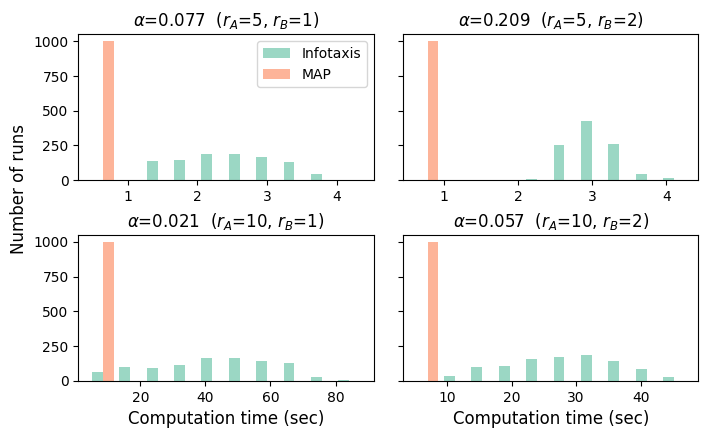

In [5]:
pmax_th = 0.95
pmax_diff_th = 1e-5

cr_all = [5, 10]
br_all = [1, 2]
pm = 0.001


colors = sns.color_palette("Set2")
alpha = 0.65

fig, ax_n = plt.subplots(2, 2, figsize=(8, 4.5), sharey=True)
fig.subplots_adjust(hspace=0.375, wspace=0.1)


for cr_seq, cr in enumerate([5, 10]):
    for br_seq, br in enumerate([1, 2]):

        alpha_grid = get_beam_search_space_ratio(cr, br)

        # Load summary and ph details
        df_infotaxis = pd.read_csv(
            path_infotaxis / get_success_fname(
                search_type="infotaxis", cr=cr, br=br, simulation_type="simple",
                pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                pm_agent=pm,
            ), index_col=0
        )
        df_MAP = pd.read_csv(
            path_MAP / get_success_fname(
                search_type="MAP", cr=cr, br=br, simulation_type="simple",
                pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                pm_agent=pm,
            ), index_col=0
        )

        ax_n[cr_seq, br_seq].hist(
            [df_infotaxis["time_proc"], df_MAP["time_proc"]],
            color=[colors[0], colors[1]], alpha=alpha
        )
        ax_n[cr_seq, br_seq].set_title(
            fr"$\alpha$={alpha_grid:.3f}  ($r_A$={cr}, $r_B$={br})",
            fontsize=12,
        )

ax_n[0, 0].legend(["Infotaxis", "MAP"])
ax_n[1, 0].set_xlabel("Computation time (sec)", fontsize=12)
ax_n[1, 1].set_xlabel("Computation time (sec)", fontsize=12)
ax_n[0, 0].set_ylabel("Number of runs                               ", fontsize=12)

plt.show()

fig.savefig(
    path_fig / f"fig_per_run_computation_time_infotaxis_MAP_cmp.png",
    dpi=300, bbox_inches="tight"
)
